In [82]:
import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [83]:
buildings = []

folder_path = os.path.abspath(os.path.join(os.getcwd(), '../results/'))
file_paths = glob.glob(os.path.join(folder_path, '*'))
files = [os.path.basename(file_path) for file_path in file_paths]

In [84]:
dataframes = {}

# Loop through each file and read into a DataFrame
for file in files:  # Assuming filenames are building_0.csv to building_15.csv
    # Read the CSV
    df = pd.read_csv('../results/' + file, index_col=0)
    file_name = file.rstrip('.csv')
    # Store only the columns 'real' and 'rmse'
    dataframes[file_name] = df[['Cost', 'MSE']]

In [85]:
# Combine all DataFrames into a single DataFrame with MultiIndex
combined_df = pd.concat(dataframes, axis=0)

In [86]:
def reset_multiindex_building_indices(df):
    # Extract the unique building names from the first level of the MultiIndex
    unique_buildings = df.index.levels[0]
    
    # Create a mapping for the new sequential building names
    new_building_names = [f'building_{i}' for i in range(len(unique_buildings))]
    building_mapping = dict(zip(unique_buildings, new_building_names))
    
    # Replace the old building names with the new names in the MultiIndex
    new_index = df.index.map(lambda idx: (building_mapping[idx[0]], idx[1]))
    
    # Assign the updated index to the dataframe
    df.index = pd.MultiIndex.from_tuples(new_index, names=df.index.names)
    
    return df

In [87]:
from sklearn.preprocessing import MinMaxScaler
# Create a new DataFrame to store scaled values
scaled_data = combined_df.copy()

# Initialize a scaler for each building and apply it
scaler = MinMaxScaler()

for i in range(0,len(files)*6,6):
    # Filter rows for the current building
    current_building = combined_df[i:i+6].copy()
    
    # Apply MinMaxScaler to 'real' and 'rmse' separately
    mse_scaled = scaler.fit_transform(current_building[['MSE']])
    cost_scaled = scaler.fit_transform(current_building[['Cost']])
    
    # Update the scaled DataFrame
    scaled_data.loc[files[int(i/6)].rstrip('.csv'),'MSE'] = mse_scaled
    scaled_data.loc[files[int(i/6)].rstrip('.csv'),'Cost'] = cost_scaled

In [101]:
scaled_data.to_csv('../results/overall_results.csv')

In [89]:
scaled_data = reset_multiindex_building_indices(scaled_data)

In [90]:
# Step 1: Reshape the DataFrame
# Reset the multi-index for easier manipulation
reshaped_df = scaled_data.reset_index()

# Pivot the DataFrame to have 'building' as columns and 'real'/'rmse' as rows
radar_df = reshaped_df.pivot_table(index='Model', columns='level_0', values=['Cost', 'MSE'])

# Flatten the column index for easier access
radar_df.columns = ['_'.join(col).strip() for col in radar_df.columns.values]

# Step 2: Prepare the radar chart
categories = radar_df.columns[:len(files)].tolist()  # Buildings as variables
N = len(categories)

In [91]:
# Calculate angles for the radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the circle

In [92]:
import re
from math import pi

def natural_sort_key(label):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', label)]

def create_radar_plot(ax, title, data, angle_labels, group_labels, strip, ylim=(0, 1)):
    # Ensure angle_labels are sorted naturally
    sorted_labels = sorted(angle_labels, key=natural_sort_key)
    
    # Ensure the data is ordered according to the sorted angle_labels
    data = data[sorted_labels]
    
    categories_stripped = []
    for building in sorted_labels:
        name = building.lstrip(strip)
        categories_stripped.append(name)
    
    sorted_labels = sorted(categories_stripped, key=natural_sort_key)    
    
    # Calculate the angles for each label
    num_vars = len(sorted_labels)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Close the circle

    # Ensure the first axis is at the top
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw one axis per variable (building) + add labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(sorted_labels, color='grey', size=11)
    
    # Draw y-labels and set limits
    ax.set_rlabel_position(0)
    ax.set_yticks([0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1"], color="grey", size=14)
    ax.set_ylim(*ylim)
    
    for label in ax.get_yticklabels():
        label.set_verticalalignment('top')
    
    # Plot each group
    for group_label, color in zip(group_labels, ['b', 'r', 'g', 'p']):
        values = data.loc[group_label].tolist()
        values += values[:1]  # Close the circle
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=group_label)
        ax.fill(angles, values, color, alpha=0.1)
    
    # Add legend and title
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=14)
    ax.set_title(title, size=15, color='blue', y=1.1)


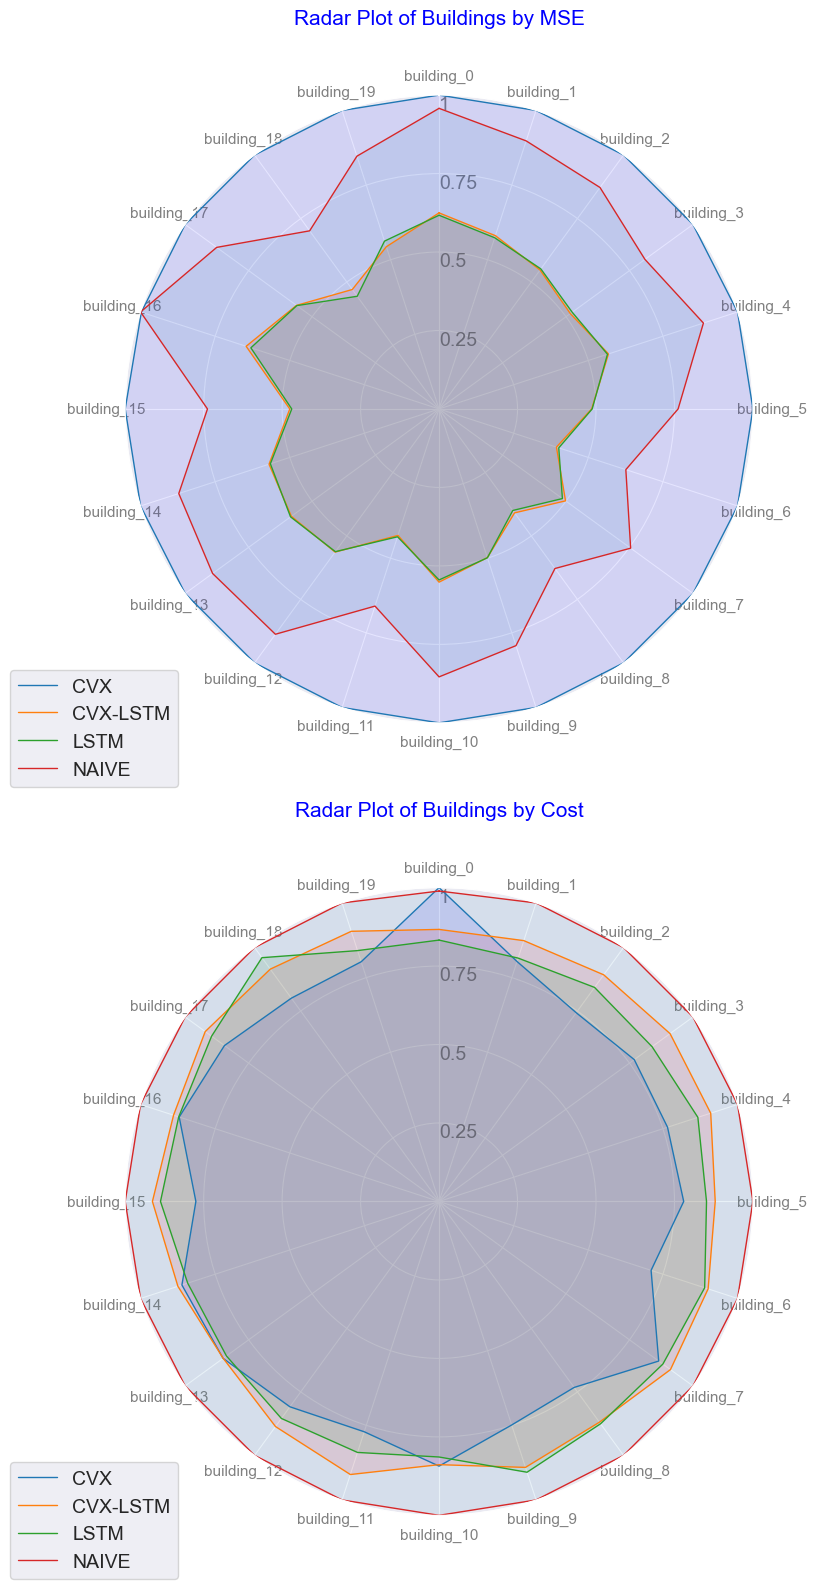

In [93]:
# Prepare figure and axes for two radar plots
fig, axs = plt.subplots(2, 1, figsize=(8, 16), subplot_kw=dict(polar=True))

# Radar Plot 1: RMSE
create_radar_plot(
    ax=axs[0],
    title="Radar Plot of Buildings by MSE",
    data=radar_df[radar_df.columns[len(files):]],  # Subset of RMSE data
    angle_labels=radar_df.columns[len(files):],
    group_labels=['CVX', 'CVX-LSTM', 'LSTM', 'NAIVE'],
    strip='MSE_'
)

# Radar Plot 2: Cost
create_radar_plot(
    ax=axs[1],
    title="Radar Plot of Buildings by Cost",
    data=radar_df[radar_df.columns[:len(files)]],  # Subset of Cost data
    angle_labels=radar_df.columns[:len(files)],
    group_labels=['CVX', 'CVX-LSTM', 'LSTM', 'NAIVE'],
    strip='Cost_'
)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

C:\Users\jdepoort\AppData\Local\Temp\ipykernel_16488\1180486571.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)
C:\Users\jdepoort\AppData\Local\Temp\ipykernel_16488\1180486571.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(["0.25", "0.5", "0.75"], fontsize=10)


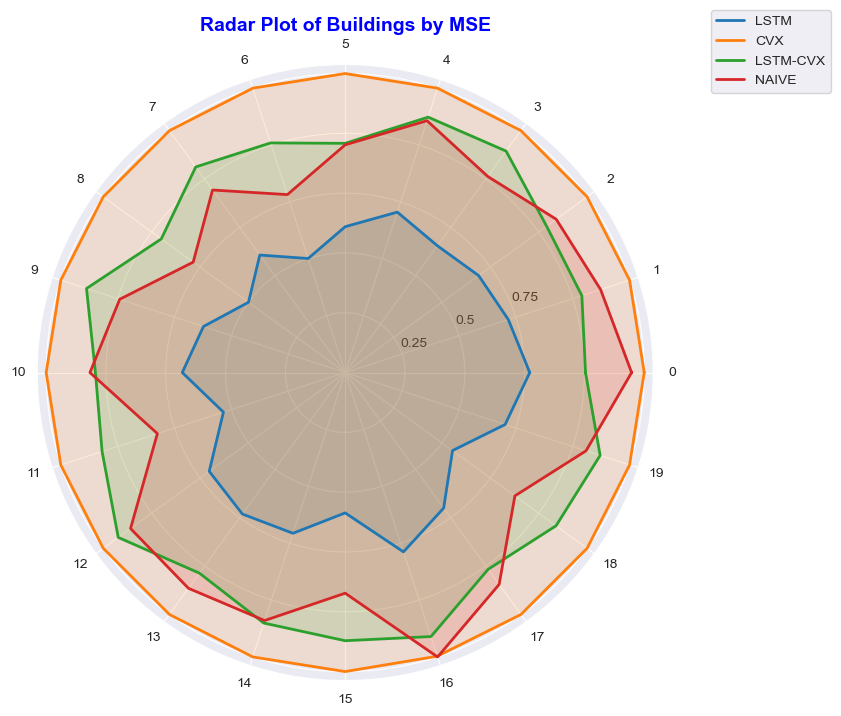

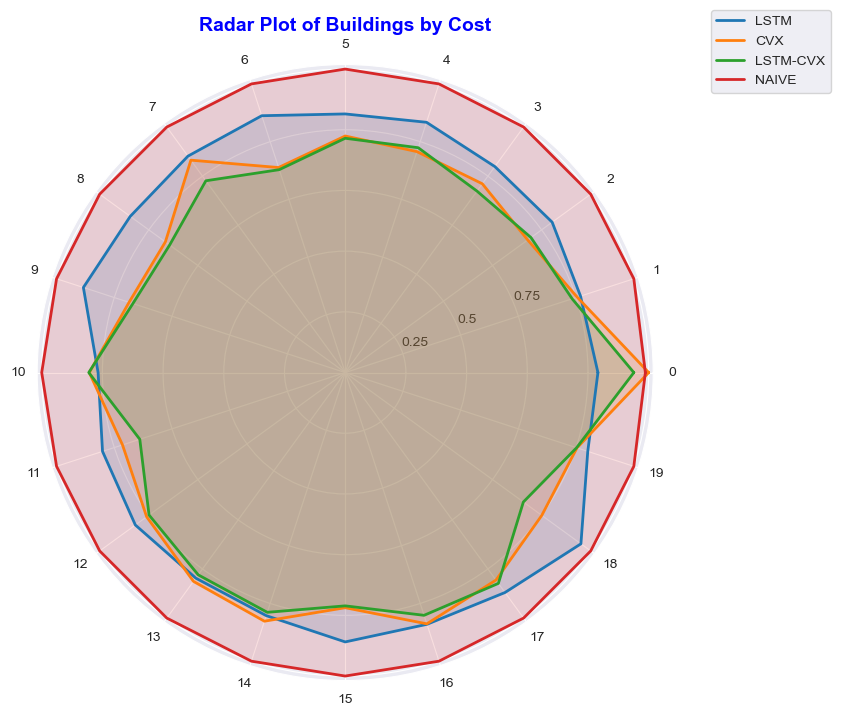

In [97]:
# Filtering out CVX-LSTM and PERFECT
# Assuming df is your dataframe
df = scaled_data.reset_index()  # Ensure the building names are a column
df.rename(columns={"level_0": "Building"}, inplace=True)  # Rename for clarity
df_filtered = df[~df["Model"].isin(["CVX-LSTM", "PERFECT"])]

# Extract building numbers instead of full names (e.g., "building_0" → "0")
df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)

# Sort buildings numerically
df_filtered = df_filtered.sort_values("Building")

# Get unique buildings and models
buildings = df_filtered["Building"].unique()
models = df_filtered["Model"].unique()

# Convert data to radar plot format
mse_data = {}
cost_data = {}

for model in models:
    mse_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["MSE"].reindex(buildings).fillna(0).values
    cost_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["Cost"].reindex(buildings).fillna(0).values


# Function to plot radar chart
def plot_radar_chart(data_dict, title):
    labels = buildings  # Buildings as labels
    num_vars = len(labels)
    
    # Compute angles
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model, values in data_dict.items():
        values = np.append(values, values[0])  # Close the loop
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.15)  # Fill the area

    # Configure labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, rotation=45)
    ax.set_yticklabels(["0.25", "0.5", "0.75"], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight="bold", color="blue")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.show()

# Plot radar charts
plot_radar_chart(mse_data, "Radar Plot of Buildings by MSE")
plot_radar_chart(cost_data, "Radar Plot of Buildings by Cost")

In [104]:
import seaborn as sns

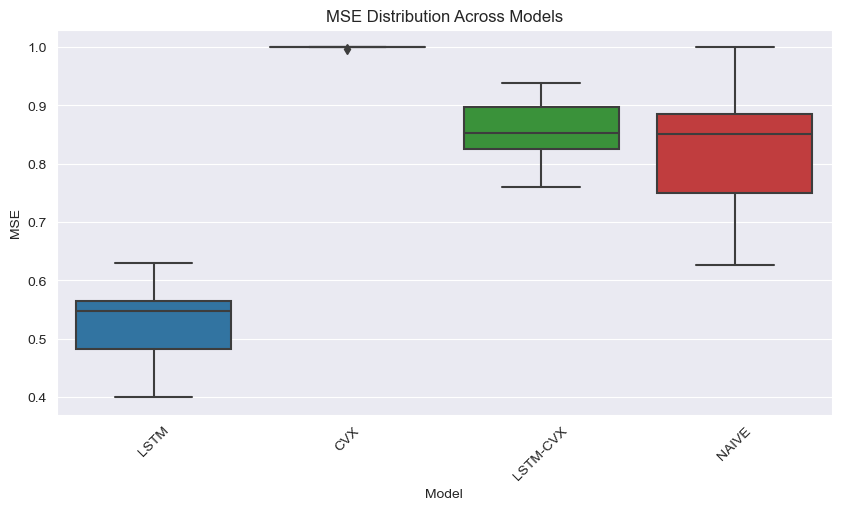

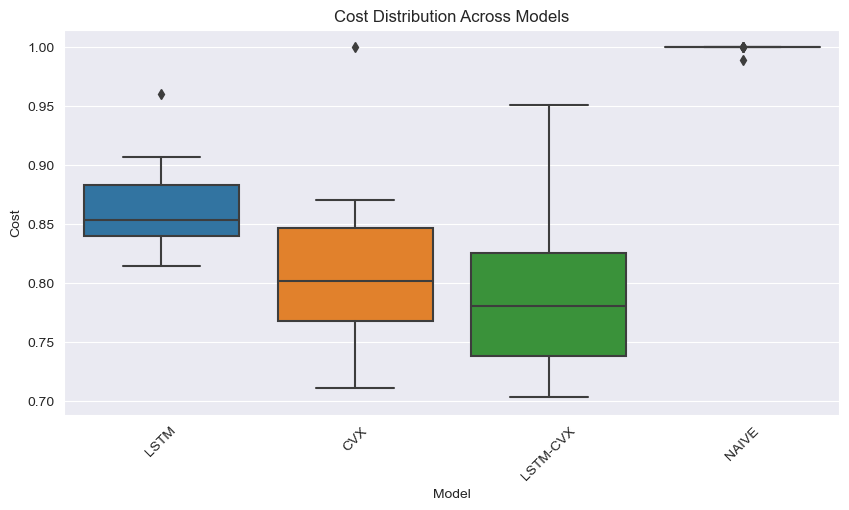

In [105]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x="Model", y="MSE")
plt.title("MSE Distribution Across Models")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x="Model", y="Cost")
plt.title("Cost Distribution Across Models")
plt.xticks(rotation=45)
plt.show()

C:\Users\jdepoort\AppData\Local\Temp\ipykernel_16488\1970392079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)


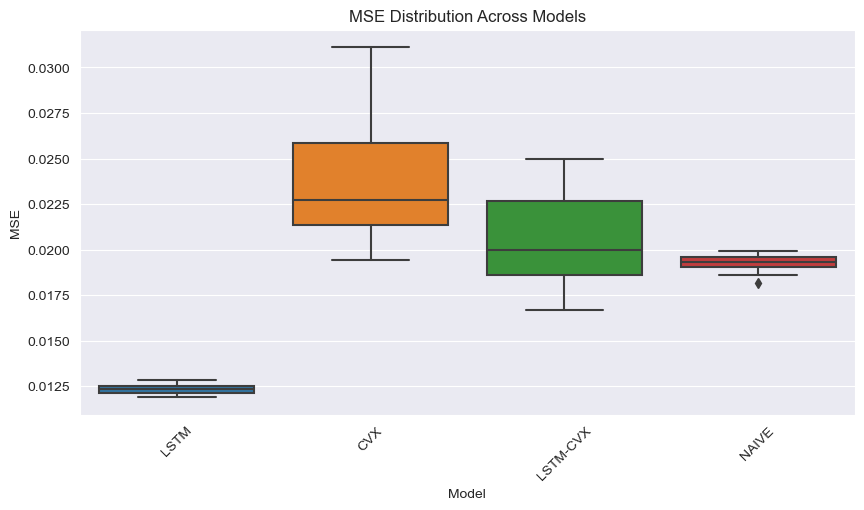

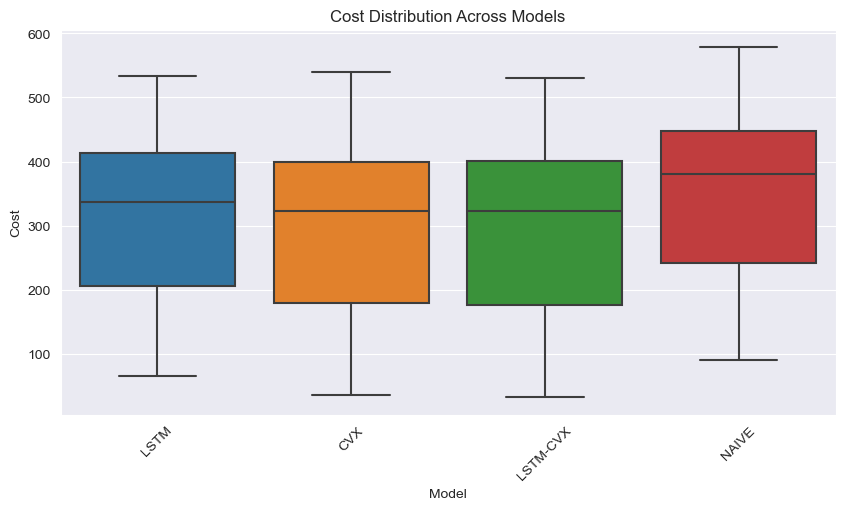

In [107]:
df = combined_df.reset_index()  # Ensure the building names are a column
df.rename(columns={"level_0": "Building"}, inplace=True)  # Rename for clarity
df_filtered = df[~df["Model"].isin(["CVX-LSTM", "PERFECT"])]

# Extract building numbers instead of full names (e.g., "building_0" → "0")
df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)

# Sort buildings numerically
df_filtered = df_filtered.sort_values("Building")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x="Model", y="MSE")
plt.title("MSE Distribution Across Models")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x="Model", y="Cost")
plt.title("Cost Distribution Across Models")
plt.xticks(rotation=45)
plt.show()

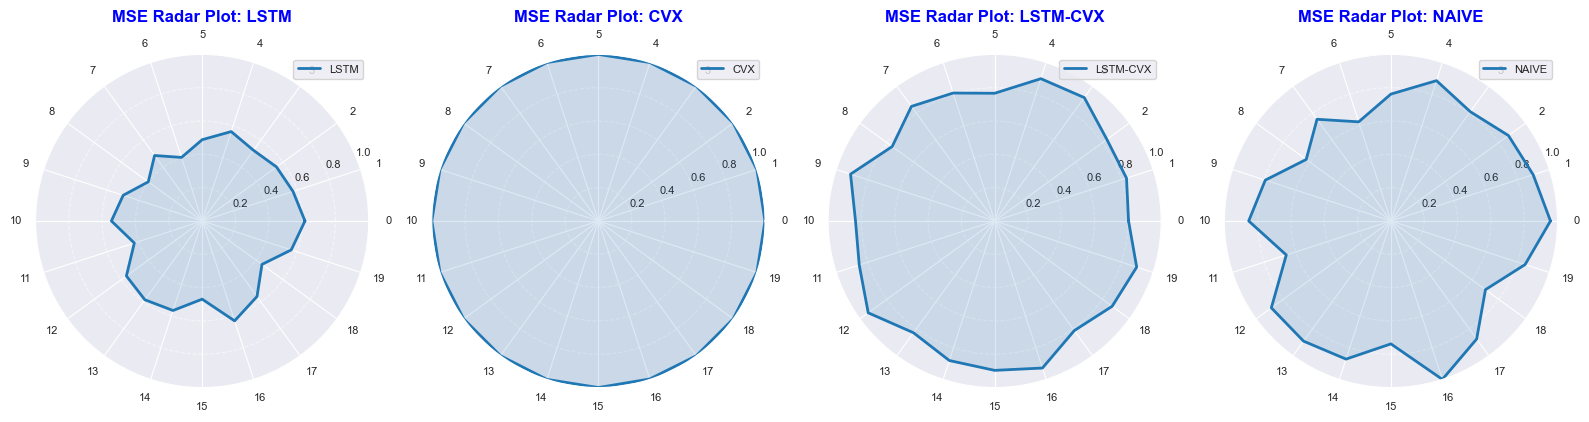

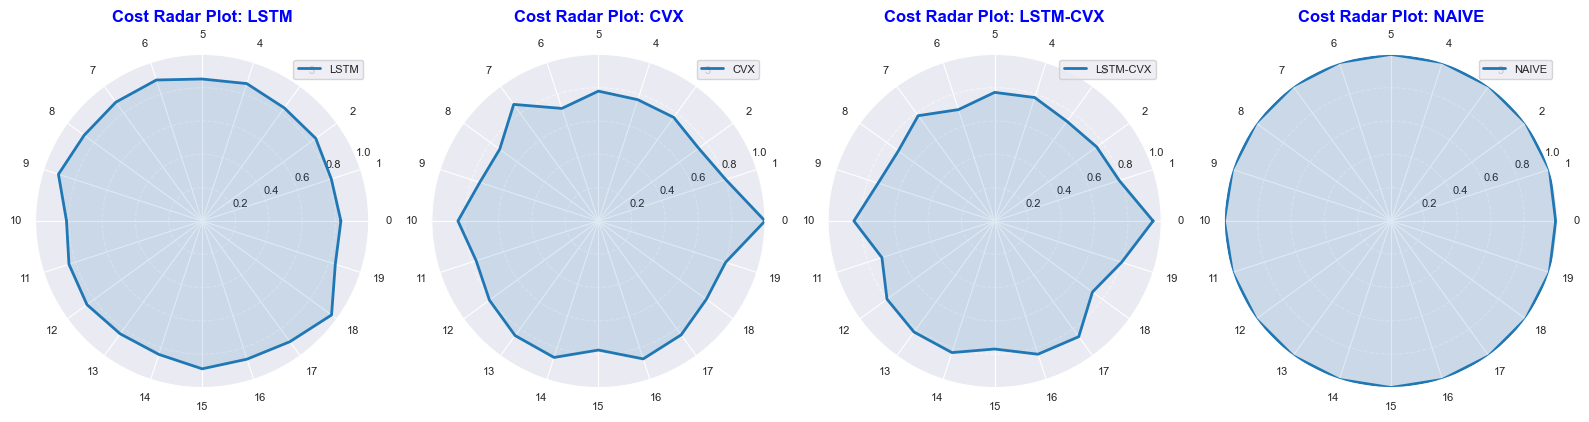

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_filtered, buildings, models, mse_data, and cost_data are already defined

# Function to plot multiple radar charts in a grid with fixed radial limits
def plot_multiple_radar_charts(data_dict, title, layout=(2, 4)):
    num_models = len(models)
    rows, cols = layout

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), subplot_kw=dict(polar=True))
    axes = axes.flatten()  # Flatten for easy iteration

    angles = np.linspace(0, 2 * np.pi, len(buildings), endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    for i, model in enumerate(models):
        values = np.append(data_dict[model], data_dict[model][0])  # Close the loop
        ax = axes[i]

        # Plot data
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.15)  # Fill the area
        
        # Set fixed radial limits
        ax.set_ylim(0, 1)  # Ensures the outer circle is always 1

        # Set radial ticks at fixed positions (0.2, 0.4, 0.6, 0.8, 1.0)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
        ax.yaxis.grid(True, linestyle="dashed", alpha=0.5)  # Dashed grid lines

        # Set angular ticks
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(buildings, fontsize=8, rotation=45)

        ax.set_title(f"{title}: {model}", fontsize=12, fontweight="bold", color="blue")
        ax.legend(loc="upper right", fontsize=8)

    # Hide unused subplots if models < total subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Plot individual radar charts for each model with fixed bands
plot_multiple_radar_charts(mse_data, "MSE Radar Plot", layout=(2, 4))  # 2 rows x 4 cols
plot_multiple_radar_charts(cost_data, "Cost Radar Plot", layout=(2, 4))  # 2 rows x 4 cols


C:\Users\jdepoort\AppData\Local\Temp\ipykernel_16488\2926253057.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)


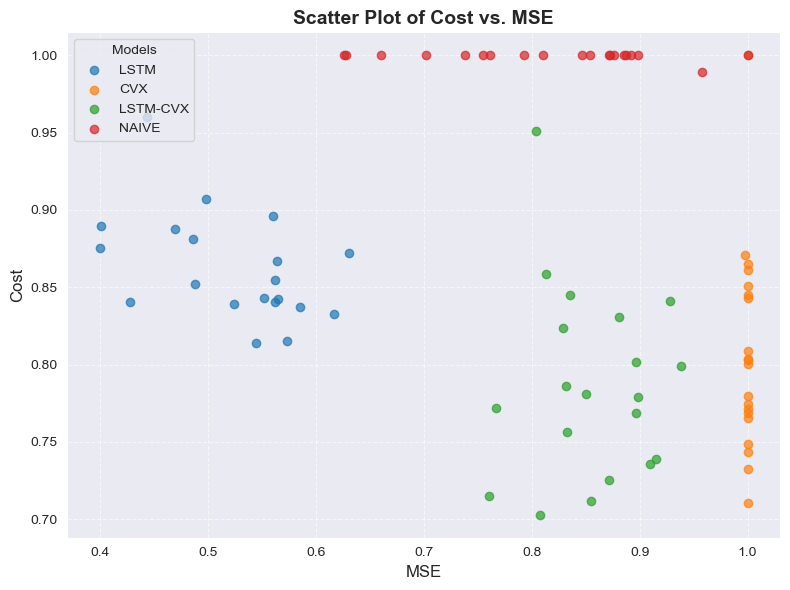

In [116]:
import matplotlib.pyplot as plt

# Assuming mse_data and cost_data are already defined
df = scaled_data.reset_index()  # Ensure the building names are a column
df.rename(columns={"level_0": "Building"}, inplace=True)  # Rename for clarity
df_filtered = df[~df["Model"].isin(["CVX-LSTM", "PERFECT"])]

# Extract building numbers instead of full names (e.g., "building_0" → "0")
df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)

# Sort buildings numerically
df_filtered = df_filtered.sort_values("Building")

# Get unique buildings and models
buildings = df_filtered["Building"].unique()
models = df_filtered["Model"].unique()

# Convert data to radar plot format
mse_data = {}
cost_data = {}

for model in models:
    mse_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["MSE"].reindex(buildings).fillna(0).values
    cost_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["Cost"].reindex(buildings).fillna(0).values


def plot_scatter_plot(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(8, 6))

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

    # Set labels and title
    plt.xlabel("MSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. MSE", fontsize=14, fontweight="bold")
    
    # Add a legend
    plt.legend(title="Models", loc="upper left", fontsize=10)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Call the function to plot the scatter plot
plot_scatter_plot(mse_data, cost_data)


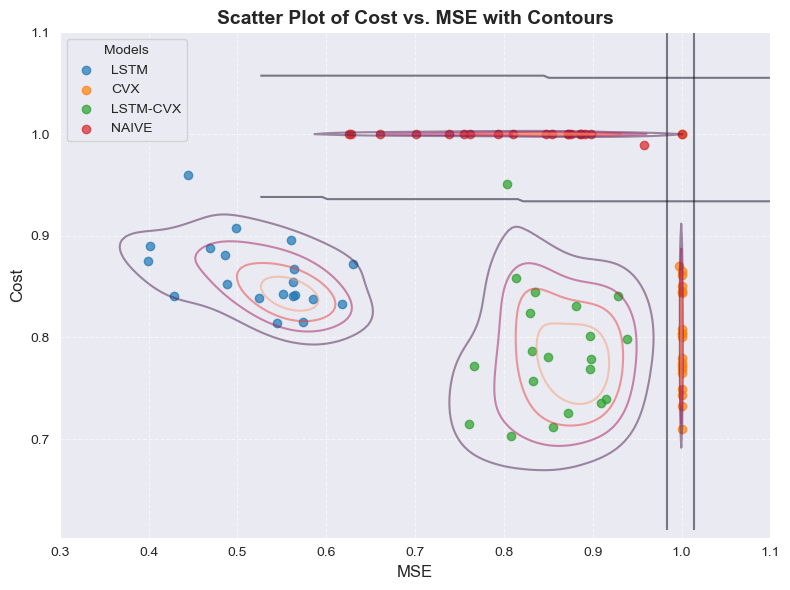

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Assuming mse_data and cost_data are already defined

def plot_scatter_plot_with_contour(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(8, 6))

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

        # Create a kernel density estimate (KDE) to smooth the scatter points
        xy = np.vstack([mse_values, cost_values])
        kde = gaussian_kde(xy)

        # Create grid for contour plot
        xmin, xmax = min(mse_values) - 0.1, max(mse_values) + 0.1
        ymin, ymax = min(cost_values) - 0.1, max(cost_values) + 0.1
        x_grid, y_grid = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
        density = kde(positions).reshape(x_grid.shape)

        # Plot contour lines
        plt.contour(x_grid, y_grid, density, levels=5, linewidths=1.5, alpha=0.5)

    # Set labels and title
    plt.xlabel("MSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. MSE with Contours", fontsize=14, fontweight="bold")
    
    # Add a legend
    plt.legend(title="Models", loc="upper left", fontsize=10)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Call the function to plot the scatter plot with contour
plot_scatter_plot_with_contour(mse_data, cost_data)


C:\Users\jdepoort\AppData\Local\Temp\ipykernel_16488\1775217621.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)


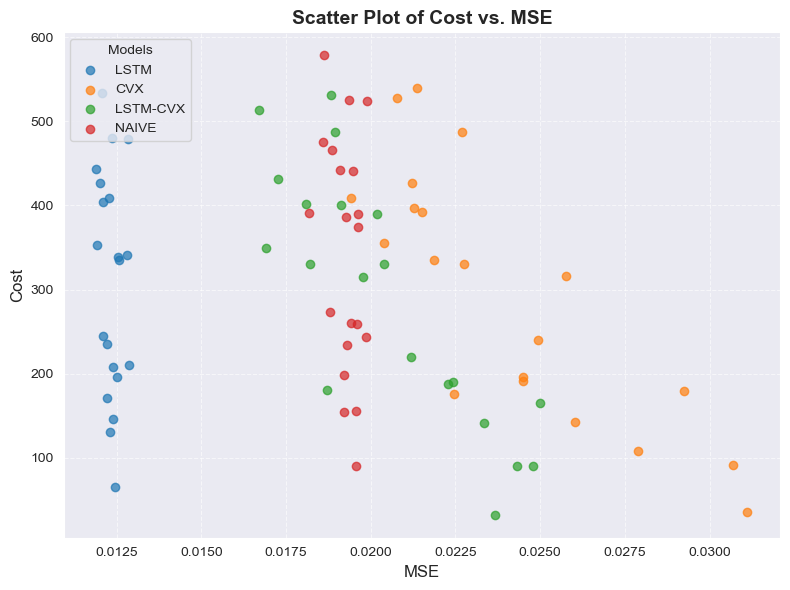

In [114]:
import matplotlib.pyplot as plt

df = combined_df.reset_index()  # Ensure the building names are a column
df.rename(columns={"level_0": "Building"}, inplace=True)  # Rename for clarity
df_filtered = df[~df["Model"].isin(["CVX-LSTM", "PERFECT"])]

# Extract building numbers instead of full names (e.g., "building_0" → "0")
df_filtered["Building"] = df_filtered["Building"].str.extract(r'(\d+)').astype(int)

# Sort buildings numerically
df_filtered = df_filtered.sort_values("Building")

# Get unique buildings and models
buildings = df_filtered["Building"].unique()
models = df_filtered["Model"].unique()

# Convert data to radar plot format
mse_data = {}
cost_data = {}

for model in models:
    mse_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["MSE"].reindex(buildings).fillna(0).values
    cost_data[model] = df_filtered[df_filtered["Model"] == model].set_index("Building")["Cost"].reindex(buildings).fillna(0).values

# Call the function to plot the scatter plot
plot_scatter_plot(mse_data, cost_data)
